# 데이터 불러오기 및 컬럼명 변경 및 데이터 + 라벨 붙이기

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
from matplotlib import rc

system = platform.system()
if system == 'Darwin':  
    rc('font', family='AppleGothic') # 한국어 깨짐 방지용


plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지용

In [85]:
train_act = pd.read_csv("/Users/leehyunsong/Desktop/최종프로젝트/헬스케어/라이프로그/01.데이터/1.Training/원천데이터/1.걸음걸이/train_activity.csv")
train_act_label = pd.read_csv("/Users/leehyunsong/Desktop/최종프로젝트/헬스케어/라이프로그/01.데이터/1.Training/라벨링데이터/1.걸음걸이/training_label.csv")

train_sleep = pd.read_csv("/Users/leehyunsong/Desktop/최종프로젝트/헬스케어/라이프로그/01.데이터/1.Training/원천데이터/2.수면/train_sleep.csv")
train_sleep_label = pd.read_csv("/Users/leehyunsong/Desktop/최종프로젝트/헬스케어/라이프로그/01.데이터/1.Training/라벨링데이터/2.수면/training_label.csv")

test_act = pd.read_csv("/Users/leehyunsong/Desktop/최종프로젝트/헬스케어/라이프로그/01.데이터/2.Validation/원천데이터/1.걸음걸이/val_activity.csv")
test_act_label = pd.read_csv("/Users/leehyunsong/Desktop/최종프로젝트/헬스케어/라이프로그/01.데이터/2.Validation/라벨링데이터/1.걸음걸이/val_label.csv")

test_sleep = pd.read_csv("/Users/leehyunsong/Desktop/최종프로젝트/헬스케어/라이프로그/01.데이터/2.Validation/원천데이터/2.수면/val_sleep.csv")
test_sleep_label = pd.read_csv("/Users/leehyunsong/Desktop/최종프로젝트/헬스케어/라이프로그/01.데이터/2.Validation/라벨링데이터/2.수면/val_label.csv")

In [86]:
print(train_act.shape)
print(train_act_label.shape)
print(train_sleep.shape)
print(train_sleep_label.shape)

print(test_act.shape)
print(test_act_label.shape)
print(test_sleep.shape)
print(test_sleep_label.shape)

(9705, 31)
(141, 2)
(9705, 36)
(141, 2)
(2478, 31)
(33, 2)
(2478, 36)
(33, 2)


In [87]:
# 컬럼이름 확인해보기
life_log_dict = {
    'train_act': train_act,
    'train_act_label': train_act_label,
    'train_sleep': train_sleep,
    'train_sleep_l': train_sleep_label,
    'test_act': test_act,
    'test_act_label': test_act_label,
    'test_sleep': test_sleep,
    'test_sleep_label': test_sleep_label
}


for name, df in life_log_dict.items():
    print(f'{name} : {df.columns.tolist()}')

train_act : ['EMAIL', 'activity_average_met', 'activity_cal_active', 'activity_cal_total', 'activity_class_5min', 'activity_daily_movement', 'activity_day_end', 'activity_day_start', 'activity_high', 'activity_inactive', 'activity_inactivity_alerts', 'activity_low', 'activity_medium', 'activity_met_1min', 'activity_met_min_high', 'activity_met_min_inactive', 'activity_met_min_low', 'activity_met_min_medium', 'activity_non_wear', 'activity_rest', 'activity_score', 'activity_score_meet_daily_targets', 'activity_score_move_every_hour', 'activity_score_recovery_time', 'activity_score_stay_active', 'activity_score_training_frequency', 'activity_score_training_volume', 'activity_steps', 'activity_total', 'CONVERT(activity_class_5min USING utf8)', 'CONVERT(activity_met_1min USING utf8)']
train_act_label : ['SAMPLE_EMAIL', 'DIAG_NM']
train_sleep : ['EMAIL', 'sleep_awake', 'sleep_bedtime_end', 'sleep_bedtime_start', 'sleep_breath_average', 'sleep_deep', 'sleep_duration', 'sleep_efficiency', 'sl

In [88]:
# SAMPLE_EMAIL을 EMAIL로 바꿔주기
for name, df in life_log_dict.items():
    df.columns = ['EMAIL'] + list(df.columns[1:])

In [89]:
train_act = pd.merge(train_act, train_act_label, on='EMAIL', how='left')
train_sleep = pd.merge(train_sleep, train_sleep_label, on='EMAIL', how='left')
test_act = pd.merge(test_act, test_act_label, on='EMAIL', how='left')
test_sleep = pd.merge(test_sleep, test_sleep_label, on='EMAIL', how='left')

In [90]:
print(train_act.shape)
print(train_sleep.shape)
print(test_act.shape)
print(test_sleep.shape)

(9705, 32)
(9705, 37)
(2478, 32)
(2478, 37)


----

# 수면과 활동 합치기

In [91]:
# 날짜 컬럼 단순하게 
train_act['activity_day_start'] = pd.to_datetime(train_act['activity_day_start'])
train_act['activity_day_start'] = train_act['activity_day_start'].dt.strftime('%Y-%m-%d %H:%M:%S')
train_act['activity_day_end'] = pd.to_datetime(train_act['activity_day_end'])
train_act['activity_day_end'] = train_act['activity_day_end'].dt.strftime('%Y-%m-%d %H:%M:%S')

In [92]:
# 날짜 컬럼 단순하게
test_act['activity_day_start'] = pd.to_datetime(test_act['activity_day_start'])
test_act['activity_day_start'] = test_act['activity_day_start'].dt.strftime('%Y-%m-%d %H:%M:%S')
test_act['activity_day_end'] = pd.to_datetime(test_act['activity_day_end'])
test_act['activity_day_end'] = test_act['activity_day_end'].dt.strftime('%Y-%m-%d %H:%M:%S')

In [93]:
# 날짜 컬럼 단순하게 
train_sleep['sleep_bedtime_start'] = pd.to_datetime(train_sleep['sleep_bedtime_start'])
train_sleep['sleep_bedtime_start'] = train_sleep['sleep_bedtime_start'].dt.strftime('%Y-%m-%d %H:%M:%S')
train_sleep['sleep_bedtime_end'] = pd.to_datetime(train_sleep['sleep_bedtime_end'])
train_sleep['sleep_bedtime_end'] = train_sleep['sleep_bedtime_end'].dt.strftime('%Y-%m-%d %H:%M:%S')

In [94]:
# 날짜 컬럼 단순하게
test_sleep['sleep_bedtime_start'] = pd.to_datetime(test_sleep['sleep_bedtime_start'])
test_sleep['sleep_bedtime_start'] = test_sleep['sleep_bedtime_start'].dt.strftime('%Y-%m-%d %H:%M:%S')
test_sleep['sleep_bedtime_end'] = pd.to_datetime(test_sleep['sleep_bedtime_end'])
test_sleep['sleep_bedtime_end'] = test_sleep['sleep_bedtime_end'].dt.strftime('%Y-%m-%d %H:%M:%S')

## pk인 EMAIL 기준으로 수면이 끝나는 일과 활동 시작 일이 같을 때 조인

In [95]:
train_sleep['sleep_end_date'] = pd.to_datetime(train_sleep['sleep_bedtime_end']).dt.date
train_act['activity_start_date'] = pd.to_datetime(train_act['activity_day_start']).dt.date
test_sleep['sleep_end_date'] = pd.to_datetime(test_sleep['sleep_bedtime_end']).dt.date
test_act['activity_start_date'] = pd.to_datetime(test_act['activity_day_start']).dt.date

In [96]:
# 수면 종료날이 중복이 발생한 것 확인 -> 각 사용자 + 수면 종료 날짜별로 최신 수면만 남김
train_sleep = train_sleep.sort_values(by='sleep_bedtime_end') \
                                .drop_duplicates(subset=['EMAIL', 'sleep_end_date'], keep='last')

test_sleep= test_sleep.sort_values(by='sleep_bedtime_end') \
                              .drop_duplicates(subset=['EMAIL', 'sleep_end_date'], keep='last')


In [97]:
train_merged = pd.merge(train_act, train_sleep, left_on=['EMAIL', 'activity_start_date'],
                        right_on=['EMAIL', 'sleep_end_date'], how='left')


test_merged = pd.merge(test_act, test_sleep, left_on=['EMAIL', 'activity_start_date'],
                       right_on=['EMAIL', 'sleep_end_date'], how='left')


In [98]:
print(train_merged.shape)
print(test_merged.shape)

(9705, 70)
(2478, 70)


In [99]:
# 필요 없으니 빠르게 삭제
train_merged = train_merged.drop(columns=['activity_start_date', 'sleep_end_date'])
test_merged = test_merged.drop(columns=['activity_start_date', 'sleep_end_date'])

In [100]:
print(train_merged.shape)
print(test_merged.shape)

(9705, 68)
(2478, 68)


In [101]:
train_merged = train_merged[train_merged['sleep_bedtime_end'].notnull()]
test_merged = test_merged[test_merged['sleep_bedtime_end'].notnull()]

In [102]:
print(train_merged.shape)
print(test_merged.shape)

(9673, 68)
(2477, 68)


-> train에서 약 30개랑 test에서 1개는 그냥 버리자..

# CONVERT 행 처리 -> 기입된 데이터를 만들 예정으로 웨어러블 링이 없으면 기입 불가한 5분,1분 로그는 버리기

In [103]:
# 얘는 사용하는 버전
# train_merged['sleep_hr_5min'] = train_merged['CONVERT(sleep_hr_5min USING utf8)'].apply(
#    lambda x: [float(i) for i in x.split('/') if i.strip() not in ['', None]] if isinstance(x, str) else []
# )

#train_merged['sleep_hypnogram_5min'] = train_merged['CONVERT(sleep_hypnogram_5min USING utf8)'].apply(
#    lambda x: [float(i) for i in x.split('/') if i.strip() not in ['', None]] if isinstance(x, str) else []
#)
#train_merged['activity_met_1min'] = train_merged['CONVERT(activity_met_1min USING utf8)'].apply(
#    lambda x: [float(i) for i in x.split('/') if i.strip() not in ['', None]] if isinstance(x, str) else []
#)
#train_merged['activity_class_5min'] = train_merged['CONVERT(activity_class_5min USING utf8)'].apply(
#    lambda x: [float(i) for i in x.split('/') if i.strip().isdigit()] if isinstance(x, str) else []
#)

#test_merged['sleep_hr_5min'] = test_merged['CONVERT(sleep_hr_5min USING utf8)'].apply(
#    lambda x: [float(i) for i in x.split('/') if i.strip() not in ['', None]] if isinstance(x, str) else []
#)

#test_merged['sleep_hypnogram_5min'] = test_merged['CONVERT(sleep_hypnogram_5min USING utf8)'].apply(
#    lambda x: [float(i) for i in x.split('/') if i.strip() not in ['', None]] if isinstance(x, str) else []
#)

# test_merged['activity_met_1min'] = test_merged['CONVERT(activity_met_1min USING utf8)'].apply(
#    lambda x: [float(i) for i in x.split('/') if i.strip() not in ['', None]] if isinstance(x, str) else []
# )

# test_merged['activity_class_5min'] = test_merged['CONVERT(activity_class_5min USING utf8)'].apply(
#    lambda x: [float(i) for i in x.split('/') if i.strip().isdigit()] if isinstance(x, str) else []
# )

# train_merged['sleep_rmssd_5min'] = train_merged['CONVERT(sleep_rmssd_5min USING utf8)'].apply(
#    lambda x: [float(i) for i in x.split('/') if i.strip() not in ['', None]] if isinstance(x, str) else []
#)

#test_merged['sleep_rmssd_5min'] = test_merged['CONVERT(sleep_rmssd_5min USING utf8)'].apply(
#    lambda x: [float(i) for i in x.split('/') if i.strip() not in ['', None]] if isinstance(x, str) else []
#)


In [104]:
# CONVERT 드랍
train_merged.drop(columns=['CONVERT(activity_met_1min USING utf8)','CONVERT(sleep_hr_5min USING utf8)', 'CONVERT(activity_class_5min USING utf8)','CONVERT(sleep_rmssd_5min USING utf8)', 'sleep_rmssd_5min', 'CONVERT(sleep_hypnogram_5min USING utf8)', 'activity_class_5min', 'sleep_hr_5min', 'sleep_hypnogram_5min', 'activity_met_1min'], inplace = True)
test_merged.drop(columns=['CONVERT(activity_met_1min USING utf8)', 'CONVERT(sleep_hr_5min USING utf8)','CONVERT(activity_class_5min USING utf8)','CONVERT(sleep_rmssd_5min USING utf8)', 'sleep_rmssd_5min', 'CONVERT(sleep_hypnogram_5min USING utf8)', 'activity_class_5min', 'sleep_hr_5min', 'sleep_hypnogram_5min', 'activity_met_1min'], inplace = True)

---

# 컬럼명 한국어로 변경하고, 일반인을 0으로, 치매환자를 1로 만들어주기

In [105]:
dict = {
    'EMAIL': '이메일',
    'activity_average_met': '하루 평균 운동 강도',
    'activity_cal_active': '하루간 활동 칼로리',
    'activity_cal_total': '하루간 총 사용 칼로리',
    'activity_daily_movement': '하루동안 움직인 거리',
    'activity_day_end': '활동 종료 시간',
    'activity_day_start': '활동 시작 시간',
    'activity_high': '고강도 활동 시간',
    'activity_inactive': '비활동 시간',
    'activity_inactivity_alerts': '비활동 알람 횟수',
    'activity_low': '저강도 활동 시간',
    'activity_medium': '중강도 활동 시간',
    'activity_met_min_high': '하루간 고강도 운동 강도',
    'activity_met_min_inactive': '하루간 비활동 운동 강도',
    'activity_met_min_low': '하루간 저강도 활동 운동 강도',
    'activity_met_min_medium': '하루간 중강도 활동 운동 강도',
    'activity_non_wear': '미착용 시간',
    'activity_rest': '휴식 시간',
    'activity_score': '활동 점수',
    'activity_score_meet_daily_targets': '활동 목표달성 점수',
    'activity_score_move_every_hour': '매 시간 당 활동유지 점수',
    'activity_score_recovery_time': '회복시간 점수',
    'activity_score_stay_active': '활동 유지 점수',
    'activity_score_training_frequency': '운동 빈도 점수',
    'activity_score_training_volume': '운동량 점수',
    'activity_steps': '매일 걸음 수',
    'activity_total': '활동 총 시간',
    'DIAG_NM_y' : '진단',
    'sleep_awake': '깬 시간',
    'sleep_bedtime_end': '잠 종료 시간',
    'sleep_bedtime_start': '잠 시작 시간',
    'sleep_breath_average': '분당 평균 호흡 수',
    'sleep_deep': '깊은 수면 시간',
    'sleep_duration': '잠 시간',
    'sleep_efficiency': '수면 효율',
    'sleep_hr_5min': '5분 당 심박동 로그',
    'sleep_hr_average': '분당 평균 심박동 수',
    'sleep_hr_lowest': '분당 낮은 심박동 수',
    'sleep_hypnogram_5min': '수면 상태 로그',
    'sleep_is_longest': '본 수면 여부',
    'sleep_light': '가벼운 수면 시간',
    'sleep_midpoint_at_delta': '수면 중간점 시간 델타',
    'sleep_midpoint_time': '수면 중간점 시간',
    'sleep_onset_latency': '수면 잠복 시간',
    'sleep_rem': '램 수면 시간',
    'sleep_restless': '뒤척임 비율',
    'sleep_rmssd': '평균 심박동 변동',
    'sleep_rmssd_5min': '5분당 심박동 변동 로그',
    'sleep_score': '수면 종합 점수',
    'sleep_score_alignment': '수면 시기 점수',
    'sleep_score_deep': '깊은 수면 점수',
    'sleep_score_disturbances': '수면 방해 점수',
    'sleep_score_efficiency': '수면 효율 점수',
    'sleep_score_latency': '수면 잠복 점수',
    'sleep_score_rem': '램수면 점수',
    'sleep_score_total': '수면 점수 총합',
    'sleep_temperature_delta': '피부 온도 편차',
    'sleep_temperature_deviation': '피부 온도 경향 편차',
    'sleep_total': '수면 시간'
}

train_merged = train_merged.rename(columns = dict)
test_merged = test_merged.rename(columns = dict)

In [106]:
# 0이 일반인, 1이 치매
train_merged['진단'] = train_merged['진단'].apply(lambda x: 0 if x == 'CN' else 1)

test_merged['진단'] = test_merged['진단'].apply(lambda x: 0 if x == 'CN' else 1)

In [107]:
train_merged.columns

Index(['이메일', '하루 평균 운동 강도', '하루간 활동 칼로리', '하루간 총 사용 칼로리', '하루동안 움직인 거리',
       '활동 종료 시간', '활동 시작 시간', '고강도 활동 시간', '비활동 시간', '비활동 알람 횟수', '저강도 활동 시간',
       '중강도 활동 시간', '하루간 고강도 운동 강도', '하루간 비활동 운동 강도', '하루간 저강도 활동 운동 강도',
       '하루간 중강도 활동 운동 강도', '미착용 시간', '휴식 시간', '활동 점수', '활동 목표달성 점수',
       '매 시간 당 활동유지 점수', '회복시간 점수', '활동 유지 점수', '운동 빈도 점수', '운동량 점수',
       '매일 걸음 수', '활동 총 시간', 'DIAG_NM_x', '깬 시간', '잠 종료 시간', '잠 시작 시간',
       '분당 평균 호흡 수', '깊은 수면 시간', '잠 시간', '수면 효율', '분당 평균 심박동 수', '분당 낮은 심박동 수',
       '본 수면 여부', '가벼운 수면 시간', '수면 중간점 시간 델타', '수면 중간점 시간', '수면 잠복 시간',
       'sleep_period_id', '램 수면 시간', '뒤척임 비율', '평균 심박동 변동', '수면 종합 점수',
       '수면 시기 점수', '깊은 수면 점수', '수면 방해 점수', '수면 효율 점수', '수면 잠복 점수', '램수면 점수',
       '수면 점수 총합', '피부 온도 편차', '피부 온도 경향 편차', '수면 시간', '진단'],
      dtype='object')

In [108]:
train_merged.drop(columns = ['DIAG_NM_x', 'sleep_period_id'], inplace = True)
train_merged.columns

Index(['이메일', '하루 평균 운동 강도', '하루간 활동 칼로리', '하루간 총 사용 칼로리', '하루동안 움직인 거리',
       '활동 종료 시간', '활동 시작 시간', '고강도 활동 시간', '비활동 시간', '비활동 알람 횟수', '저강도 활동 시간',
       '중강도 활동 시간', '하루간 고강도 운동 강도', '하루간 비활동 운동 강도', '하루간 저강도 활동 운동 강도',
       '하루간 중강도 활동 운동 강도', '미착용 시간', '휴식 시간', '활동 점수', '활동 목표달성 점수',
       '매 시간 당 활동유지 점수', '회복시간 점수', '활동 유지 점수', '운동 빈도 점수', '운동량 점수',
       '매일 걸음 수', '활동 총 시간', '깬 시간', '잠 종료 시간', '잠 시작 시간', '분당 평균 호흡 수',
       '깊은 수면 시간', '잠 시간', '수면 효율', '분당 평균 심박동 수', '분당 낮은 심박동 수', '본 수면 여부',
       '가벼운 수면 시간', '수면 중간점 시간 델타', '수면 중간점 시간', '수면 잠복 시간', '램 수면 시간',
       '뒤척임 비율', '평균 심박동 변동', '수면 종합 점수', '수면 시기 점수', '깊은 수면 점수', '수면 방해 점수',
       '수면 효율 점수', '수면 잠복 점수', '램수면 점수', '수면 점수 총합', '피부 온도 편차', '피부 온도 경향 편차',
       '수면 시간', '진단'],
      dtype='object')

In [109]:
test_merged.columns

Index(['이메일', '하루 평균 운동 강도', '하루간 활동 칼로리', '하루간 총 사용 칼로리', '하루동안 움직인 거리',
       '활동 종료 시간', '활동 시작 시간', '고강도 활동 시간', '비활동 시간', '비활동 알람 횟수', '저강도 활동 시간',
       '중강도 활동 시간', '하루간 고강도 운동 강도', '하루간 비활동 운동 강도', '하루간 저강도 활동 운동 강도',
       '하루간 중강도 활동 운동 강도', '미착용 시간', '휴식 시간', '활동 점수', '활동 목표달성 점수',
       '매 시간 당 활동유지 점수', '회복시간 점수', '활동 유지 점수', '운동 빈도 점수', '운동량 점수',
       '매일 걸음 수', '활동 총 시간', 'DIAG_NM_x', '깬 시간', '잠 종료 시간', '잠 시작 시간',
       '분당 평균 호흡 수', '깊은 수면 시간', '잠 시간', '수면 효율', '분당 평균 심박동 수', '분당 낮은 심박동 수',
       '본 수면 여부', '가벼운 수면 시간', '수면 중간점 시간 델타', '수면 중간점 시간', '수면 잠복 시간',
       'sleep_period_id', '램 수면 시간', '뒤척임 비율', '평균 심박동 변동', '수면 종합 점수',
       '수면 시기 점수', '깊은 수면 점수', '수면 방해 점수', '수면 효율 점수', '수면 잠복 점수', '램수면 점수',
       '수면 점수 총합', '피부 온도 편차', '피부 온도 경향 편차', '수면 시간', '진단'],
      dtype='object')

In [110]:
test_merged.drop(columns = ['DIAG_NM_x', 'sleep_period_id'], inplace = True)
test_merged.columns

Index(['이메일', '하루 평균 운동 강도', '하루간 활동 칼로리', '하루간 총 사용 칼로리', '하루동안 움직인 거리',
       '활동 종료 시간', '활동 시작 시간', '고강도 활동 시간', '비활동 시간', '비활동 알람 횟수', '저강도 활동 시간',
       '중강도 활동 시간', '하루간 고강도 운동 강도', '하루간 비활동 운동 강도', '하루간 저강도 활동 운동 강도',
       '하루간 중강도 활동 운동 강도', '미착용 시간', '휴식 시간', '활동 점수', '활동 목표달성 점수',
       '매 시간 당 활동유지 점수', '회복시간 점수', '활동 유지 점수', '운동 빈도 점수', '운동량 점수',
       '매일 걸음 수', '활동 총 시간', '깬 시간', '잠 종료 시간', '잠 시작 시간', '분당 평균 호흡 수',
       '깊은 수면 시간', '잠 시간', '수면 효율', '분당 평균 심박동 수', '분당 낮은 심박동 수', '본 수면 여부',
       '가벼운 수면 시간', '수면 중간점 시간 델타', '수면 중간점 시간', '수면 잠복 시간', '램 수면 시간',
       '뒤척임 비율', '평균 심박동 변동', '수면 종합 점수', '수면 시기 점수', '깊은 수면 점수', '수면 방해 점수',
       '수면 효율 점수', '수면 잠복 점수', '램수면 점수', '수면 점수 총합', '피부 온도 편차', '피부 온도 경향 편차',
       '수면 시간', '진단'],
      dtype='object')

# 모델 

In [111]:
# 사용할 컬럼 ->  시간들이랑, 이메일이랑 진단만 뺌

features = ['하루 평균 운동 강도', '하루간 활동 칼로리', '하루간 총 사용 칼로리', '하루동안 움직인 거리',
         '고강도 활동 시간', '비활동 시간', '비활동 알람 횟수', '저강도 활동 시간',
       '중강도 활동 시간', '하루간 고강도 운동 강도', '하루간 비활동 운동 강도', '하루간 저강도 활동 운동 강도',
       '하루간 중강도 활동 운동 강도', '미착용 시간', '휴식 시간', '활동 점수', '활동 목표달성 점수',
       '매 시간 당 활동유지 점수', '회복시간 점수', '활동 유지 점수', '운동 빈도 점수', '운동량 점수',
       '매일 걸음 수', '활동 총 시간', '깬 시간', '분당 평균 호흡 수',
       '깊은 수면 시간', '잠 시간', '수면 효율', '분당 평균 심박동 수', '분당 낮은 심박동 수', '본 수면 여부',
       '가벼운 수면 시간', '수면 중간점 시간 델타', '수면 중간점 시간', '수면 잠복 시간', '램 수면 시간',
       '뒤척임 비율', '평균 심박동 변동', '수면 종합 점수', '수면 시기 점수', '깊은 수면 점수', '수면 방해 점수',
       '수면 효율 점수', '수면 잠복 점수', '램수면 점수', '수면 점수 총합', '피부 온도 편차', '피부 온도 경향 편차',
       '수면 시간']

In [112]:
# 시퀀스 만들자
def sequence(df):
    sequence = []
    labels = []
    email_list = df['이메일'].unique()
    for email in email_list:
        df1 = df[df['이메일'] == email].sort_values('활동 시작 시간') # 이메일,시간별로
        X = df1[features].values
        sequence.append(X)
        label = df1['진단'].iloc[0] # 이메일 별로 진단 한개니까 걍 하나만
        labels.append(label)
    return sequence, labels

train_seqs, y_train = sequence(train_merged)
test_seqs, y_test = sequence(test_merged)

In [113]:
# 사람마다 입력된 기간 다르니까 최대값에 맞추기
from tensorflow.keras.preprocessing.sequence import pad_sequences


max_len = max(max([len(s) for s in train_seqs]), max([len(s) for s in test_seqs]))
train_padded = pad_sequences(train_seqs, maxlen = max_len, dtype= 'float32', padding = 'post', value = -1.0) # 길이 못 맞춘 애들은 -1 대입해주기
test_padded = pad_sequences(test_seqs, maxlen = max_len, dtype= 'float32', padding = 'post', value = -1.0)

In [114]:
# 스케일링 - 시퀀스 형태라서 reshape해서 적용 후 다시 원복
from sklearn.preprocessing import StandardScaler

samples, steps, features = train_padded.shape
scaler = StandardScaler()
train_reshaped = train_padded.reshape(-1, features)
test_reshaped = test_padded.reshape(-1, features)

x_train = scaler.fit_transform(train_reshaped).reshape(samples, steps, features)
x_test = scaler.transform(test_reshaped).reshape(test_padded.shape[0], max_len, features)



In [ ]:
import numpy as np
from collections import Counter

y_train = np.array(y_train)

print("📌 SMOTE 적용 전")
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("y_train class distribution:", Counter(y_train))

# SMOTE 적용
samples, steps, features = x_train.shape
x_train_2d = x_train.reshape(samples, steps * features)

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train_2d, y_train)

x_train_resampled_3d = x_train_resampled.reshape(-1, steps, features)

print("\n📌 SMOTE 적용 후")
print("x_train shape:", x_train_resampled_3d.shape)
print("y_train shape:", y_train_resampled.shape)
print("y_train class distribution:", Counter(y_train_resampled))

# 교체
x_train = x_train_resampled_3d
y_train = y_train_resampled



📌 SMOTE 적용 전
x_train shape: (141, 122, 50)
y_train shape: (141,)
y_train class distribution: Counter({0: 85, 1: 56})

📌 SMOTE 적용 후
x_train shape: (170, 122, 50)
y_train shape: (170,)
y_train class distribution: Counter({1: 85, 0: 85})


In [116]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

In [117]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, f1_score, recall_score
from sklearn.utils import class_weight
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Masking, LayerNormalization
import tensorflow.keras.backend as K

model = Sequential([
    Masking(mask_value=-1.0, input_shape=(x_train.shape[1], x_train.shape[2])),
    Bidirectional(LSTM(64, return_sequences=True)),
    LayerNormalization(),
    Dropout(0.3),
    LSTM(32),
    LayerNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

def focal_loss(gamma, alpha):
    def focal_loss_fixed(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
        pt_1 = tf.where(K.equal(y_true, 1), y_pred, K.ones_like(y_pred))
        pt_0 = tf.where(K.equal(y_true, 0), y_pred, K.zeros_like(y_pred))
        return -K.mean(alpha * K.pow(1. - pt_1, gamma) * K.log(pt_1)) \
               -K.mean((1 - alpha) * K.pow(pt_0, gamma) * K.log(1. - pt_0))
    return focal_loss_fixed

model.compile(
    loss=focal_loss(gamma=1.5, alpha=0.85),  # 치매 class weight ↑
    optimizer='adam',
    metrics=['accuracy']
)


# 조기 종료 콜백
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 학습
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=2
)

# 테스트 예측
y_pred_proba = model.predict(x_test)
y_pred = (y_pred_proba > 0.5).astype(int)

# 평가
print("Classification Report (Test):")
print(classification_report(y_test, y_pred, digits=4))

f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Test F1-score: {f1:.4f}")
print(f"Test Recall: {recall:.4f}")


Epoch 1/50


/Users/leehyunsong/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 - 5s - 906ms/step - accuracy: 0.4706 - loss: 0.1418 - val_accuracy: 0.5000 - val_loss: 0.0787
Epoch 2/50
5/5 - 0s - 99ms/step - accuracy: 0.5000 - loss: 0.0885 - val_accuracy: 0.5000 - val_loss: 0.0863
Epoch 3/50
5/5 - 0s - 100ms/step - accuracy: 0.5000 - loss: 0.0882 - val_accuracy: 0.5000 - val_loss: 0.0791
Epoch 4/50
5/5 - 1s - 104ms/step - accuracy: 0.5074 - loss: 0.0825 - val_accuracy: 0.5000 - val_loss: 0.0778
Epoch 5/50
5/5 - 1s - 102ms/step - accuracy: 0.4853 - loss: 0.0854 - val_accuracy: 0.5000 - val_loss: 0.0777
Epoch 6/50
5/5 - 1s - 104ms/step - accuracy: 0.5147 - loss: 0.0730 - val_accuracy: 0.5000 - val_loss: 0.0780
Epoch 7/50
5/5 - 1s - 108ms/step - accuracy: 0.4926 - loss: 0.0829 - val_accuracy: 0.5000 - val_loss: 0.0779
Epoch 8/50
5/5 - 0s - 96ms/step - accuracy: 0.5074 - loss: 0.0822 - val_accuracy: 0.5000 - val_loss: 0.0775
Epoch 9/50
5/5 - 1s - 100ms/step - accuracy: 0.5074 - loss: 0.0789 - val_accuracy: 0.5000 - val_loss: 0.0772
Epoch 10/50
5/5 - 0s - 96ms/step

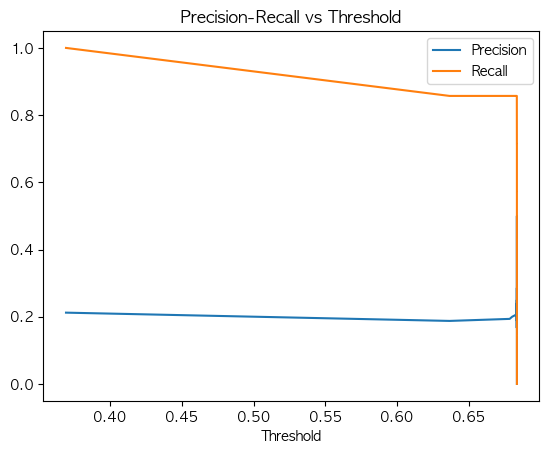

In [118]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
import matplotlib.pyplot as plt

plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel("Threshold")
plt.legend()
plt.title("Precision-Recall vs Threshold")
plt.show()


In [119]:
from sklearn.metrics import f1_score
import numpy as np


f1_scores = []
thresholds_to_try = thresholds  

for t in thresholds_to_try:
    y_pred_thresh = (y_pred_proba > t).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    f1_scores.append(f1)


best_idx = np.argmax(f1_scores)
best_threshold = thresholds_to_try[best_idx]
print(f"Best Threshold: {best_threshold:.4f}")
print(f"Best F1-score: {f1_scores[best_idx]:.4f}")


Best Threshold: 0.6835
Best F1-score: 0.3750


Classification Report (Optimized Threshold):
              precision    recall  f1-score   support

           0     0.8750    0.2692    0.4118        26
           1     0.2400    0.8571    0.3750         7

    accuracy                         0.3939        33
   macro avg     0.5575    0.5632    0.3934        33
weighted avg     0.7403    0.3939    0.4040        33



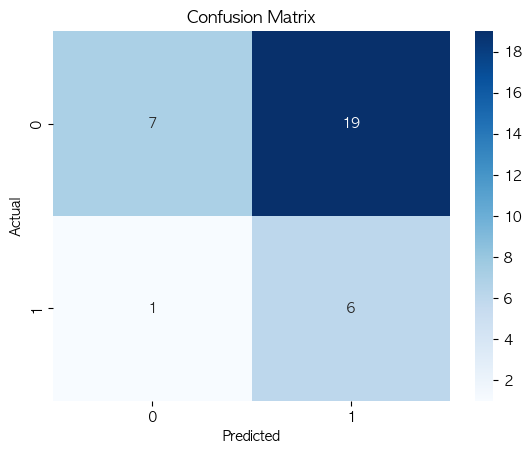

In [120]:

y_pred_final = (y_pred_proba > best_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report (Optimized Threshold):")
print(classification_report(y_test, y_pred_final, digits=4))


import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


----

# final_model1.h5

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 341ms/step
Classification Report (Optimized Threshold):
              precision    recall  f1-score   support

           0     0.9474    0.6923    0.8000        26
           1     0.4286    0.8571    0.5714         7

    accuracy                         0.7273        33
   macro avg     0.6880    0.7747    0.6857        33
weighted avg     0.8373    0.7273    0.7515        33



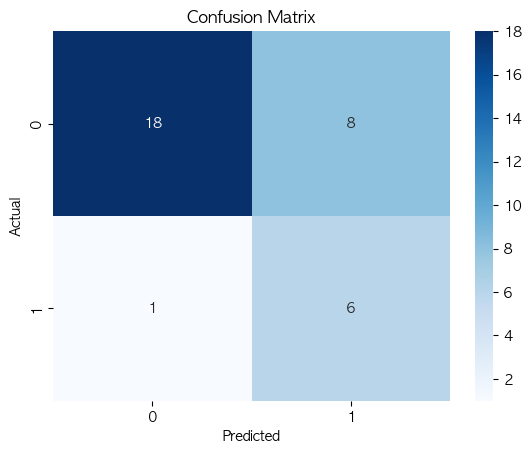

In [121]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import joblib
import tensorflow.keras.backend as K

# focal loss 재정의 (같이 있어야 함)
def focal_loss(gamma, alpha):
    def focal_loss_fixed(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
        pt_1 = tf.where(K.equal(y_true, 1), y_pred, K.ones_like(y_pred))
        pt_0 = tf.where(K.equal(y_true, 0), y_pred, K.zeros_like(y_pred))
        return -K.mean(alpha * K.pow(1. - pt_1, gamma) * K.log(pt_1)) \
               -K.mean((1 - alpha) * K.pow(pt_0, gamma) * K.log(1. - pt_0))
    return focal_loss_fixed

# focal loss wrapper
focal_loss_fn = focal_loss(gamma=1.5, alpha=0.85)

# 모델 불러오기 (SavedModel 형식)
model = tf.keras.models.load_model("final_model1.h5", custom_objects={'focal_loss_fixed': focal_loss_fn})

# threshold 불러오기
best_threshold = joblib.load("best_threshold1.pkl")

# 예측
y_pred_proba = model.predict(x_test)
y_pred_final = (y_pred_proba > best_threshold).astype(int)

print("Classification Report (Optimized Threshold):")
print(classification_report(y_test, y_pred_final, digits=4))

cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# final_model2.h5

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 374ms/step
Classification Report (Optimized Threshold):
              precision    recall  f1-score   support

           0     0.9524    0.7692    0.8511        26
           1     0.5000    0.8571    0.6316         7

    accuracy                         0.7879        33
   macro avg     0.7262    0.8132    0.7413        33
weighted avg     0.8564    0.7879    0.8045        33



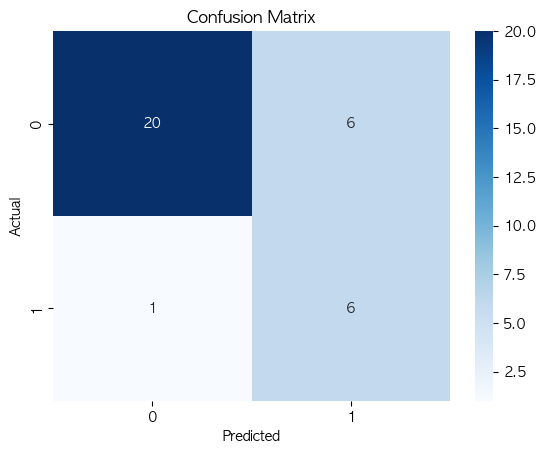

In [122]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import joblib
import tensorflow.keras.backend as K

# focal loss 재정의 (같이 있어야 함)
def focal_loss(gamma, alpha):
    def focal_loss_fixed(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
        pt_1 = tf.where(K.equal(y_true, 1), y_pred, K.ones_like(y_pred))
        pt_0 = tf.where(K.equal(y_true, 0), y_pred, K.zeros_like(y_pred))
        return -K.mean(alpha * K.pow(1. - pt_1, gamma) * K.log(pt_1)) \
               -K.mean((1 - alpha) * K.pow(pt_0, gamma) * K.log(1. - pt_0))
    return focal_loss_fixed

# focal loss wrapper
focal_loss_fn = focal_loss(gamma=1.5, alpha=0.85)

# 모델 불러오기 (SavedModel 형식)
model = tf.keras.models.load_model("final_model2.h5", custom_objects={'focal_loss_fixed': focal_loss_fn})

# threshold 불러오기
best_threshold = joblib.load("best_threshold2.pkl")

# 예측
y_pred_proba = model.predict(x_test)
y_pred_final = (y_pred_proba > best_threshold).astype(int)

print("Classification Report (Optimized Threshold):")
print(classification_report(y_test, y_pred_final, digits=4))

cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
